In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("../data/clinical_clean.csv")
print("Shape:", df.shape)
df.head()

Shape: (1036, 11)


,cases.case_id,demographic.gender,demographic.age_at_index,demographic.vital_status,demographic.days_to_death,diagnoses.days_to_last_follow_up,diagnoses.ajcc_pathologic_stage,diagnoses.primary_diagnosis,demographic.race,demographic.ethnicity,days_to_event
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,female,60.0,Alive,NaN,337.0,Stage IA,"Infiltrating duct carcinoma, NOS",white,not hispanic or latino,337.0
1,0045349c-69d9-4306-a403-c9c1fa836644,female,70.0,Alive,NaN,259.0,Stage I,Adenoid cystic carcinoma,white,not hispanic or latino,259.0
2,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,female,50.0,Alive,NaN,3102.0,Stage IIB,Apocrine adenocarcinoma,white,not hispanic or latino,3102.0
3,00a2d166-78c9-4687-a195-3d6315c27574,female,56.0,Alive,NaN,5.0,Stage IIA,"Infiltrating duct carcinoma, NOS",white,not hispanic or latino,5.0
4,01263518-5f7c-49dc-8d7e-84b0c03a6a63,female,76.0,Alive,NaN,304.0,Stage IV,"Infiltrating duct carcinoma, NOS",not reported,not reported,304.0


In [3]:
# Checking distribution fo tumoral stage
print("AJCC Pathologic Stage:")
print(df['diagnoses.ajcc_pathologic_stage'].value_counts())

print("\n\nPrimary Diagnosis (top 10):")
print(df['diagnoses.primary_diagnosis'].value_counts().head(10))

AJCC Pathologic Stage:
diagnoses.ajcc_pathologic_stage
Stage IIA     332
Stage IIB     235
Stage IIIA    138
Stage IA       82
Stage I        80
Stage IIIC     56
Stage IIIB     23
Stage IV       18
Stage II        7
Stage X         7
Stage IB        6
Name: count, dtype: int64


Primary Diagnosis (top 10):
diagnoses.primary_diagnosis
Infiltrating duct carcinoma, NOS                            735
Lobular carcinoma, NOS                                      182
Infiltrating duct and lobular carcinoma                      27
Infiltrating duct mixed with other types of carcinoma        17
Mucinous adenocarcinoma                                      14
Metaplastic carcinoma, NOS                                   13
Not Reported                                                  7
Infiltrating lobular mixed with other types of carcinoma      6
Intraductal papillary adenocarcinoma with invasion            6
Medullary carcinoma, NOS                                      5
Name: count, dtype: int

This is exactly the classical distribution of breast cancer: the majority of cases (Stage II) and the predominant histological type is Infiltrating duct carcinoma (~71%), in line with what is reported in the literature.

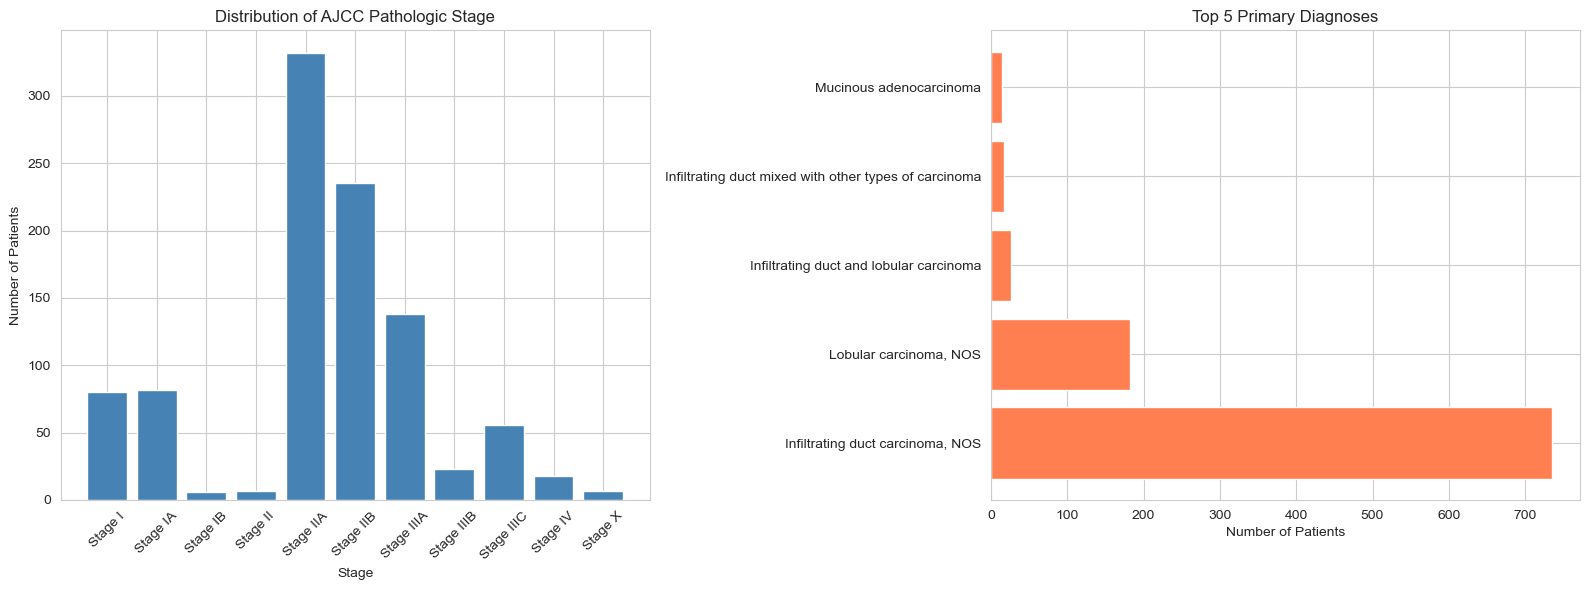

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stage distribution
stage_order = ['Stage I', 'Stage IA', 'Stage IB', 'Stage II', 'Stage IIA', 'Stage IIB',
               'Stage IIIA', 'Stage IIIB', 'Stage IIIC', 'Stage IV', 'Stage X']
stage_counts = df['diagnoses.ajcc_pathologic_stage'].value_counts().reindex(stage_order).dropna()

axes[0].bar(stage_counts.index, stage_counts.values, color='steelblue')
axes[0].set_title('Distribution of AJCC Pathologic Stage')
axes[0].set_xlabel('Stage')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)

# Top 5 diagnoses
top_diag = df['diagnoses.primary_diagnosis'].value_counts().head(5)
axes[1].barh(top_diag.index, top_diag.values, color='coral')
axes[1].set_title('Top 5 Primary Diagnoses')
axes[1].set_xlabel('Number of Patients')

plt.tight_layout()
plt.savefig('../results/plots/stage_diagnosis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Stage and Diagnosis Distribution

This visualization explores the distribution of two key clinical variables: AJCC pathologic stage and primary diagnosis type.

The left panel shows patient counts across cancer stages, ordered from earliest (Stage I) to most advanced (Stage IV). The right panel shows the five most common histological diagnoses in the cohort.

Most patients are diagnosed at Stage II, and the predominant histological subtype is Infiltrating duct carcinoma, consistent with known breast cancer epidemiology.

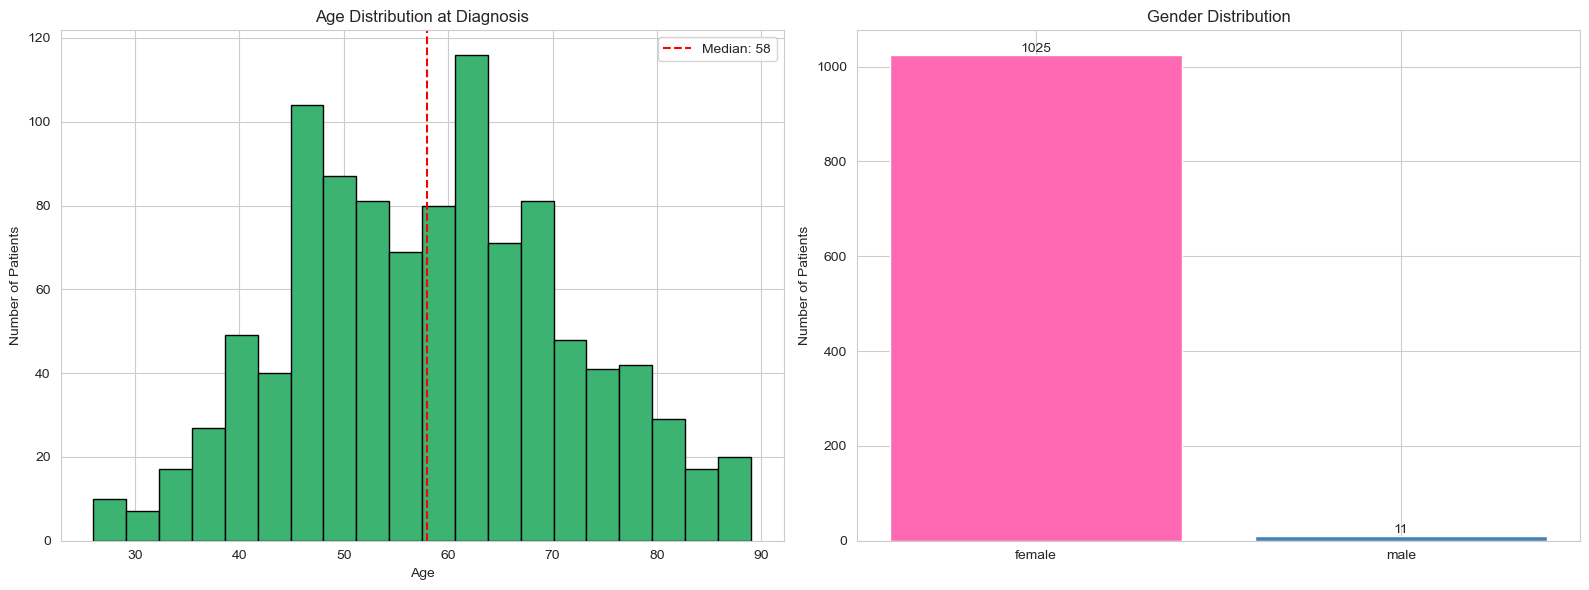


Average age: 58.4
Median age: 58.0

Gender distribution :
demographic.gender
female    1025
male        11
Name: count, dtype: int64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age distribution
axes[0].hist(df['demographic.age_at_index'], bins=20, color='mediumseagreen', edgecolor='black')
axes[0].set_title('Age Distribution at Diagnosis')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Patients')
axes[0].axvline(df['demographic.age_at_index'].median(), color='red', linestyle='--', label=f"Median: {df['demographic.age_at_index'].median():.0f}")
axes[0].legend()

# Gender distribution
gender_counts = df['demographic.gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=['hotpink', 'steelblue'])
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('Number of Patients')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.savefig('../results/plots/age_gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage age: {df['demographic.age_at_index'].mean():.1f}")
print(f"Median age: {df['demographic.age_at_index'].median():.1f}")
print(f"\nGender distribution :\n{gender_counts}")

## Age and Gender Distribution

This section examines the demographic composition of the cohort: patient age at diagnosis and gender distribution.

Age at diagnosis follows a roughly normal distribution, with a median around the late 50s, consistent with typical breast cancer epidemiology.

The cohort is overwhelmingly female (1,025 patients) with a small number of male breast cancer cases (11 patients) a rare but clinically significant subgroup, as male breast cancer often presents with distinct molecular characteristics and outcomes.

C:\Users\Santi\AppData\Local\Temp\ipykernel_12092\185481733.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stage, x='diagnoses.ajcc_pathologic_stage', y='demographic.age_at_index',


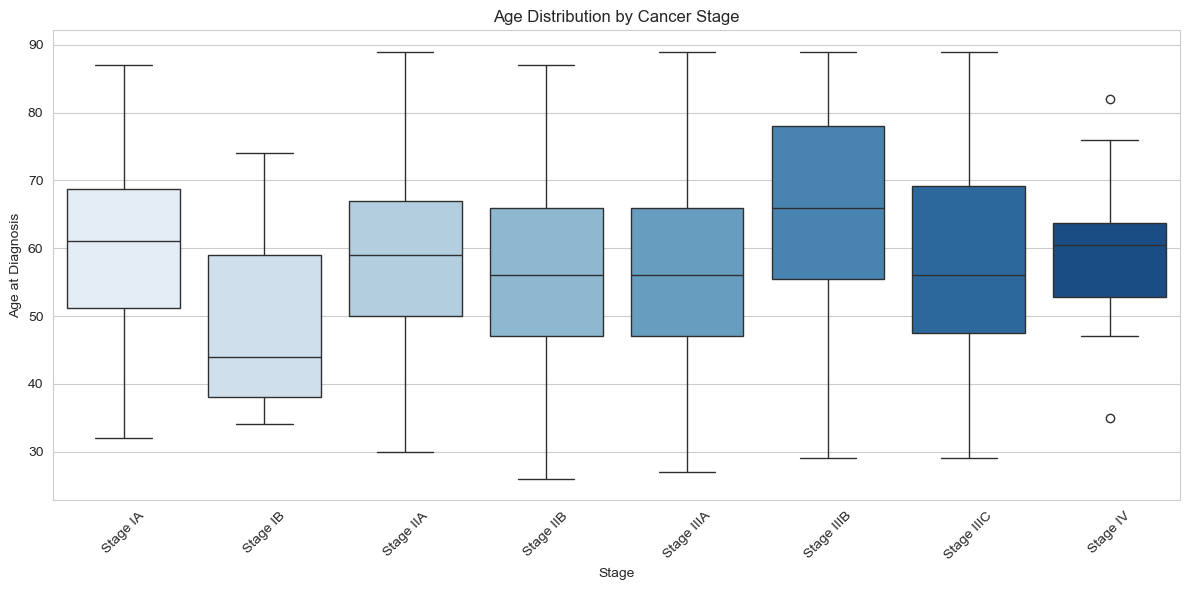

In [9]:
# Filter only main stages (excluding rare substages like Stage X)
main_stages = ['Stage IA', 'Stage IB', 'Stage IIA', 'Stage IIB', 'Stage IIIA', 'Stage IIIB', 'Stage IIIC', 'Stage IV']
df_stage = df[df['diagnoses.ajcc_pathologic_stage'].isin(main_stages)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_stage, x='diagnoses.ajcc_pathologic_stage', y='demographic.age_at_index', 
            order=main_stages, palette='Blues')
plt.title('Age Distribution by Cancer Stage')
plt.xlabel('Stage')
plt.ylabel('Age at Diagnosis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/plots/age_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

## Age Distribution by Cancer Stage

This boxplot illustrates the distribution of patients' ages at diagnosis across different cancer stages, ranging from Stage IA to Stage IV.

### Key Findings

- **Stage IB** shows the youngest patient population overall, with a median age of approximately **44 years**.
- **Stage IIIB** has the highest median age, around **66 years**, indicating that patients diagnosed at this stage tend to be older.
- Most cancer stages exhibit a broad age range, with diagnoses occurring between approximately **25 and 90 years** of age.
- **Stage IA, IIA, and IV** have median ages close to **60 years**, suggesting a relatively older patient population.
- The interquartile ranges (IQRs) indicate substantial variability in age across all stages, particularly in **Stage IIIB** and **Stage IIIC**.
- **Stage IV** presents a more concentrated age distribution around the median, although a few outliers are visible, including younger and older patients.
- Several stages show overlapping age distributions, suggesting that age alone may not be a strong differentiating factor between cancer stages at diagnosis.

### Interpretation

The chart suggests that cancer diagnosis occurs across a wide age spectrum regardless of stage. While some stages, such as **Stage IIIB**, are associated with older median ages, the considerable overlap among distributions indicates that factors other than age likely play a significant role in disease progression and stage at diagnosis.

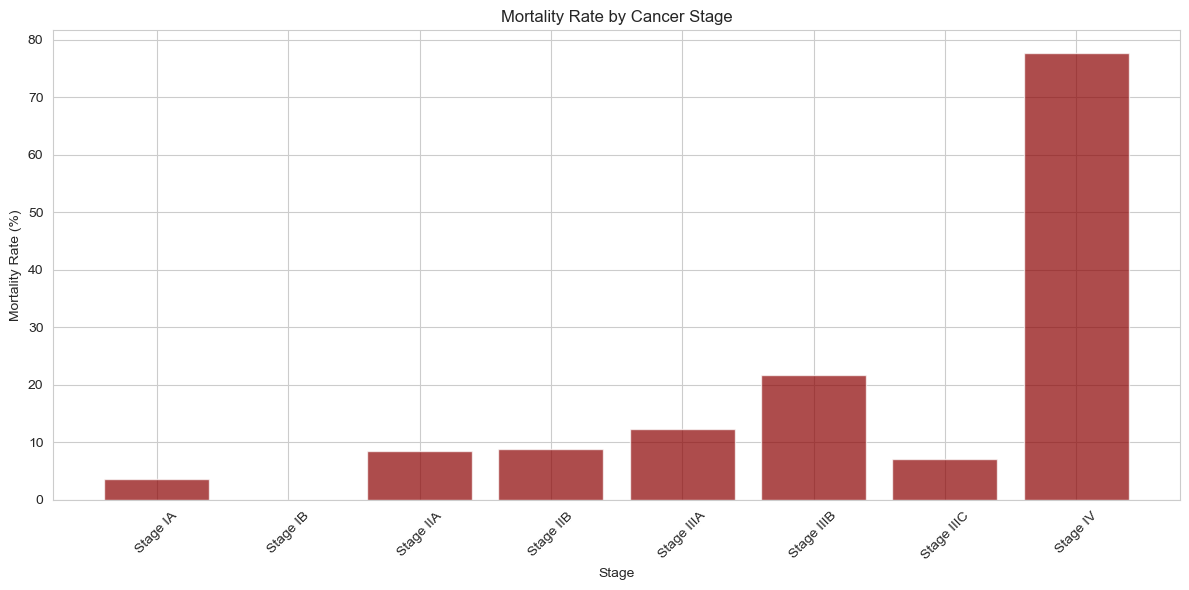

diagnoses.ajcc_pathologic_stage
Stage IA       3.658537
Stage IB       0.000000
Stage IIA      8.433735
Stage IIB      8.936170
Stage IIIA    12.318841
Stage IIIB    21.739130
Stage IIIC     7.142857
Stage IV      77.777778
Name: demographic.vital_status, dtype: float64


In [10]:
# Mortality rate
mortality_by_stage = df_stage.groupby('diagnoses.ajcc_pathologic_stage')['demographic.vital_status'].apply(
    lambda x: (x == 'Dead').sum() / len(x) * 100
).reindex(main_stages)

plt.figure(figsize=(12, 6))
plt.bar(mortality_by_stage.index, mortality_by_stage.values, color='darkred', alpha=0.7)
plt.title('Mortality Rate by Cancer Stage')
plt.xlabel('Stage')
plt.ylabel('Mortality Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/plots/mortality_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

print(mortality_by_stage)

## Mortality Rate by Stage

This plot shows the mortality rate (percentage of deceased patients) for each cancer stage.

The overall trend follows clinical expectations: mortality is low in early stages (IA-IIB, roughly 4-9%) and increases sharply in Stage IV (~78%), consistent with the well-established link between stage at diagnosis and prognosis.

Stage IIIB shows a higher mortality rate (~22%), which breaks the expected monotonic increase across substages. With only 23 patients in this subgroup, the result corresponds to roughly 5 deaths, a small enough sample that this is more likely a statistical artifact than a true biological signal, and should not be over-interpreted without a larger cohort or confidence intervals.

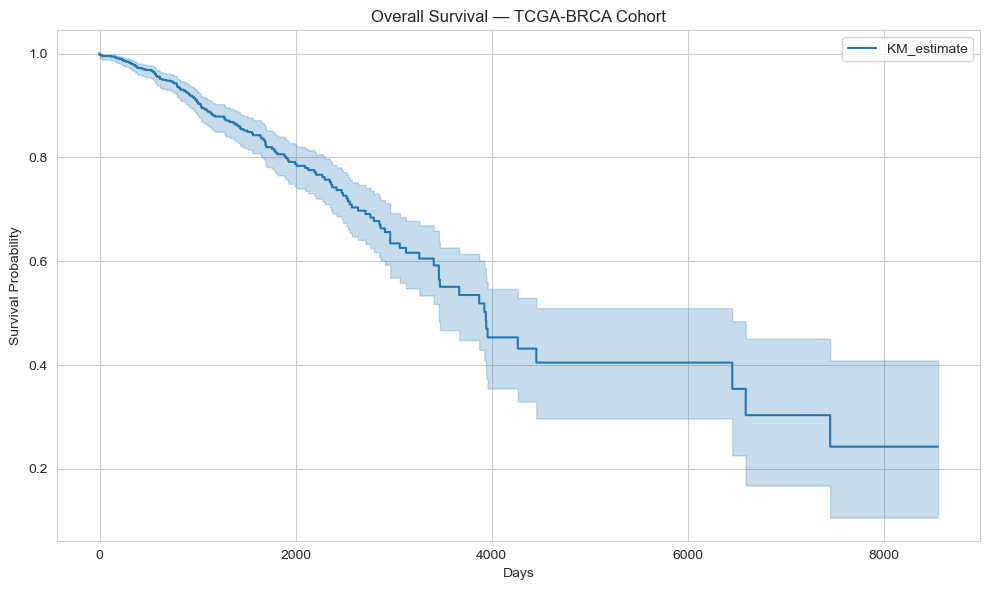

Median survival: 3941.0


In [11]:
from lifelines import KaplanMeierFitter

# (1 = dead, 0 = alive)
df['event'] = (df['demographic.vital_status'] == 'Dead').astype(int)

kmf = KaplanMeierFitter()
kmf.fit(durations=df['days_to_event'], event_observed=df['event'])

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Overall Survival — TCGA-BRCA Cohort')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.tight_layout()
plt.savefig('../results/plots/kaplan_meier_overall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median survival: {kmf.median_survival_time_}")

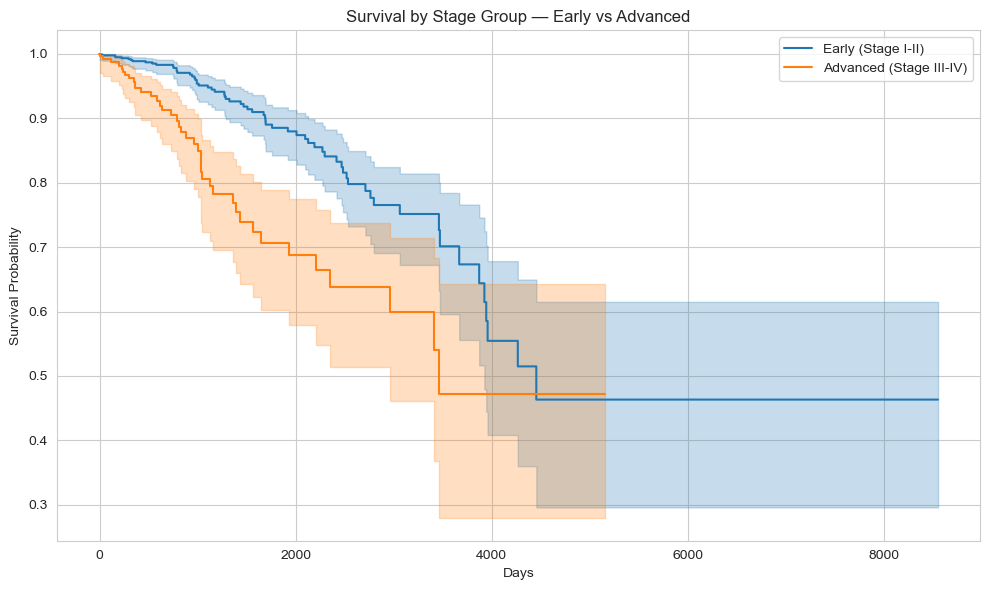

Pazienti Early: 742, Pazienti Advanced: 235


In [12]:
#  "Early" (I-II) vs "Advanced" (III-IV)
def stage_group(stage):
    if pd.isna(stage):
        return np.nan
    if stage.startswith('Stage I') and not stage.startswith('Stage II') and not stage.startswith('Stage III') and not stage.startswith('Stage IV'):
        return 'Early (I-II)'
    elif stage.startswith('Stage II') and not stage.startswith('Stage III'):
        return 'Early (I-II)'
    elif stage.startswith('Stage III') or stage.startswith('Stage IV'):
        return 'Advanced (III-IV)'
    else:
        return np.nan

df['stage_group'] = df['diagnoses.ajcc_pathologic_stage'].apply(stage_group)

plt.figure(figsize=(10, 6))
kmf_early = KaplanMeierFitter()
kmf_adv = KaplanMeierFitter()

early = df[df['stage_group'] == 'Early (I-II)']
advanced = df[df['stage_group'] == 'Advanced (III-IV)']

kmf_early.fit(early['days_to_event'], early['event'], label='Early (Stage I-II)')
kmf_early.plot_survival_function()

kmf_adv.fit(advanced['days_to_event'], advanced['event'], label='Advanced (Stage III-IV)')
kmf_adv.plot_survival_function()

plt.title('Survival by Stage Group — Early vs Advanced')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.tight_layout()
plt.savefig('../results/plots/kaplan_meier_by_stage_group.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pazienti Early: {len(early)}, Pazienti Advanced: {len(advanced)}")

## Survival by Stage Group: Early vs Advanced

This Kaplan-Meier analysis compares overall survival between patients diagnosed at an early stage (I-II, n=742) versus an advanced stage (III-IV, n=235).

The two curves show a clear separation, with the advanced-stage group experiencing a faster decline in survival probability over time compared to the early-stage group. This confirms the strong prognostic value of stage at diagnosis in this cohort, consistent with established clinical knowledge in breast cancer.

This finding reinforces the clinical importance of early detection: patients diagnosed at Stage I-II have meaningfully better long-term survival outcomes than those diagnosed at Stage III-IV.

## Summary of Key Findings

- The cohort consists of 1,036 TCGA-BRCA patients, predominantly female (99%), with a median age at diagnosis in the late 50s.
- The most common histological subtype is Infiltrating duct carcinoma (~71% of cases), consistent with known breast cancer epidemiology.
- Most patients were diagnosed at Stage II, with mortality rates increasing from ~\5-9% in early stages to ~78% in Stage IV.
- Stage IIIB showed a higher-than-expected mortality rate compared to neighboring substages, likely attributable to its small sample size (n=23) rather than a genuine biological effect.
- Kaplan-Meier survival analysis confirmed a clear and clinically meaningful separation in overall survival between early-stage (I-II) and advanced-stage (III-IV) patients, reinforcing the prognostic importance of stage at diagnosis.

These findings are consistent with established breast cancer clinical knowledge, validating the dataset and the analysis pipeline as a solid foundation for further work (e.g. integrating molecular/genomic data, or building predictive survival models).